# 05 — Trực quan hóa Dữ liệu Khám phá (EDA Visualizations)
**Người thực hiện:** Lê Trần Ngọc Quí — (Trực quan hóa)  
**Người phân tích insight:** Lê Nhật Việt — (Phân tích)

**Nhiệm vụ:**
1. ( Quí ) - Lập trình tập hợp 8 biểu đồ chuyên nghiệp bằng `Matplotlib`, `Seaborn` và `Plotly`. 
2. ( Việt ) - Viết 2-3 câu diễn giải insight kinh doanh cho mỗi biểu đồ.

**Input:** `data/processed/cafeland_features.csv`

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
df = pd.read_csv('../data/processed/cafeland_features.csv')
df['gia_ty'] = df['gia'] / 1e9
df['price_per_m2_trieu'] = df['price_per_m2'] / 1e6

## 1. Phân phối Tổng quan (Univariate Analysis)
Mục tiêu: Đánh giá nhanh hình dáng phân phối của Giá bán và Diện tích để nắm bắt phân khúc lõi của dữ liệu thu thập được.

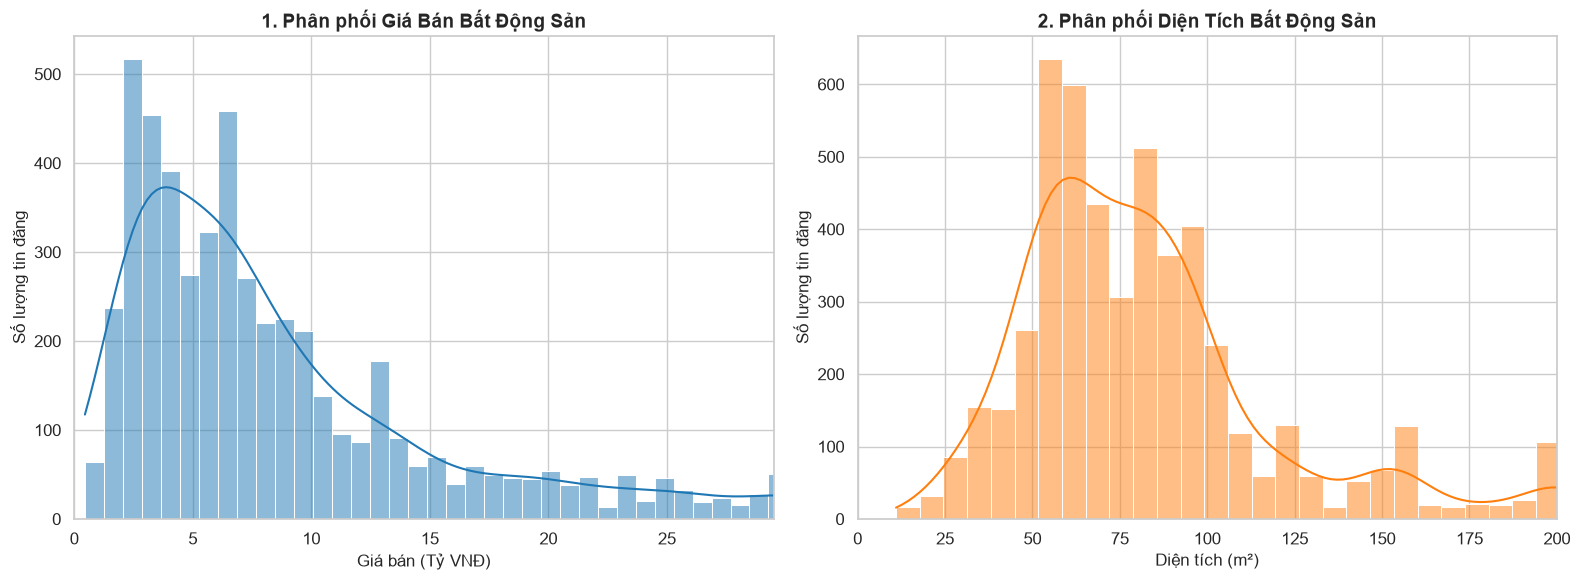

In [15]:
# Biểu đồ 1 & 2: Phân phối Giá bán và Diện tích
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df['gia_ty'], kde=True, bins=50, color='#1f77b4', ax=ax[0])
ax[0].set_title('1. Phân phối Giá Bán Bất Động Sản', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Giá bán (Tỷ VNĐ)', fontsize=12)
ax[0].set_ylabel('Số lượng tin đăng', fontsize=12)
ax[0].set_xlim(0, df['gia_ty'].quantile(0.95)) # Cắt đuôi ngoại lai top 5% để dễ nhìn

sns.histplot(df['dien_tich'], kde=True, bins=50, color='#ff7f0e', ax=ax[1])
ax[1].set_title('2. Phân phối Diện Tích Bất Động Sản', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Diện tích (m²)', fontsize=12)
ax[1].set_ylabel('Số lượng tin đăng', fontsize=12)
ax[1].set_xlim(0, df['dien_tich'].quantile(0.95))

plt.tight_layout()
plt.show()

- Giá bất động sản tập trung chủ yếu ở khoảng 2–10 tỷ đồng, trong đó nhóm 3–7 tỷ xuất hiện khá nhiều, cho thấy nguồn cung đang tập trung vào phân khúc có mức giá vừa phải, trong khi các sản phẩm trên 15 tỷ có tần suất thấp hơn
- Cho thấy thị trường có nhu cầu lớn ở phân khúc trung cấp. Trong bối cảnh TP.HCM mở rộng địa giới sau khi hợp nhất với Bình Dương và Bà Rịa–Vũng Tàu từ 1/7/2025
- Diện tích bất động sản tập trung mạnh trong khoảng 50–100 m², phản ánh nhóm sản phẩm có quy mô vừa đang chiếm tỷ trọng đáng kể
- Sau sáp nhập, TP.HCM có diện tích hơn 6.772 km², mở rộng không gian phát triển và quỹ đất, vì vậy doanh nghiệp có thể xem xét phát triển đa dạng sản phẩm theo đặc điểm từng khu vực
- Insight kinh doanh: doanh nghiệp có thể phân khúc sản phẩm theo từng khu vực và xây dựng nhiều mức giá thay vì áp dụng một chiến lược chung cho toàn thị trường

## 2. Bản đồ Nhiệt Thị phần & Phân khúc (Plotly Treemap)
Mục tiêu: Sử dụng Plotly để đáp ứng yêu cầu biểu đồ tương tác đa chiều (Số lượng tin + Giá trung bình + Khu vực + Loại hình).

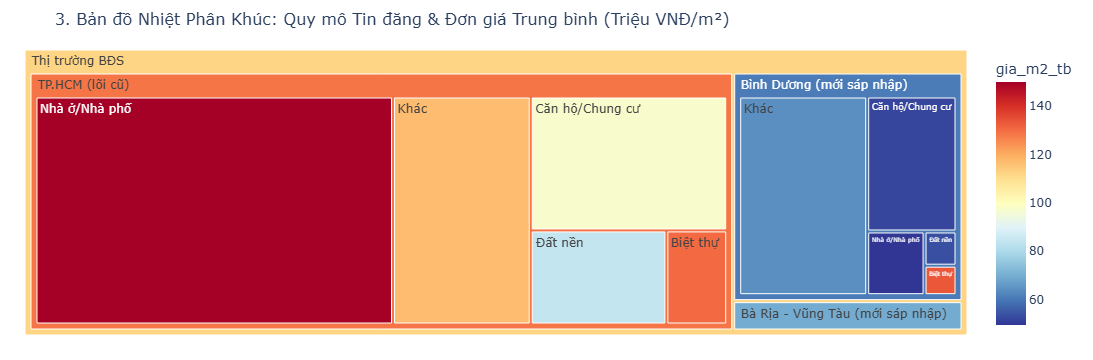

In [8]:
# Biểu đồ 3: Plotly Treemap
tree_data = df.groupby(['khu_vuc_nhom', 'loai_bds']).agg(
    so_luong=('tieu_de', 'count'),
    gia_m2_tb=('price_per_m2_trieu', 'mean')
).reset_index()

fig = px.treemap(
    tree_data,
    path=[px.Constant("Thị trường BĐS"), 'khu_vuc_nhom', 'loai_bds'],
    values='so_luong',
    color='gia_m2_tb',
    color_continuous_scale='RdYlBu_r',
    title='3. Bản đồ Nhiệt Phân Khúc: Quy mô Tin đăng & Đơn giá Trung bình (Triệu VNĐ/m²)'
)
fig.update_layout(margin=dict(t=50, l=25, r=25, b=25), title_font_size=16)
fig.show()

- Nhà ở/Nhà phố chiếm diện tích lớn nhất trên bản đồ, cho thấy đây là nhóm có quy mô tin đăng nổi bật trong dữ liệu TP.HCM, đồng thời màu đỏ đậm thể hiện đơn giá trung bình/m² ở mức cao
- Căn hộ/Chung cư cũng có lượng tin đáng kể nhưng đơn giá trung bình thấp hơn, khoảng 97,4 triệu VNĐ/m²
- Sau khi TP.HCM hợp nhất với Bình Dương và Bà Rịa–Vũng Tàu từ 1/7/2025, tạo ra sự đa dạng lớn hơn về phân khúc, giá đất và loại hình bất động sản
- Insight kinh doanh: doanh nghiệp nên phân tích riêng từng khu vực thay vì dùng mặt bằng giá của TP.HCM cũ làm đại diện cho toàn thị trường mới, đặc biệt khi mở rộng sang các khu vực có đặc điểm nguồn cung khác nhau

## 3. Phân tích So sánh Định giá (Bivariate Analysis)
Mục tiêu: Đánh giá sự phân hóa về mức giá ($VNĐ/m^2$) giữa các vùng sáp nhập và các loại hình BĐS.

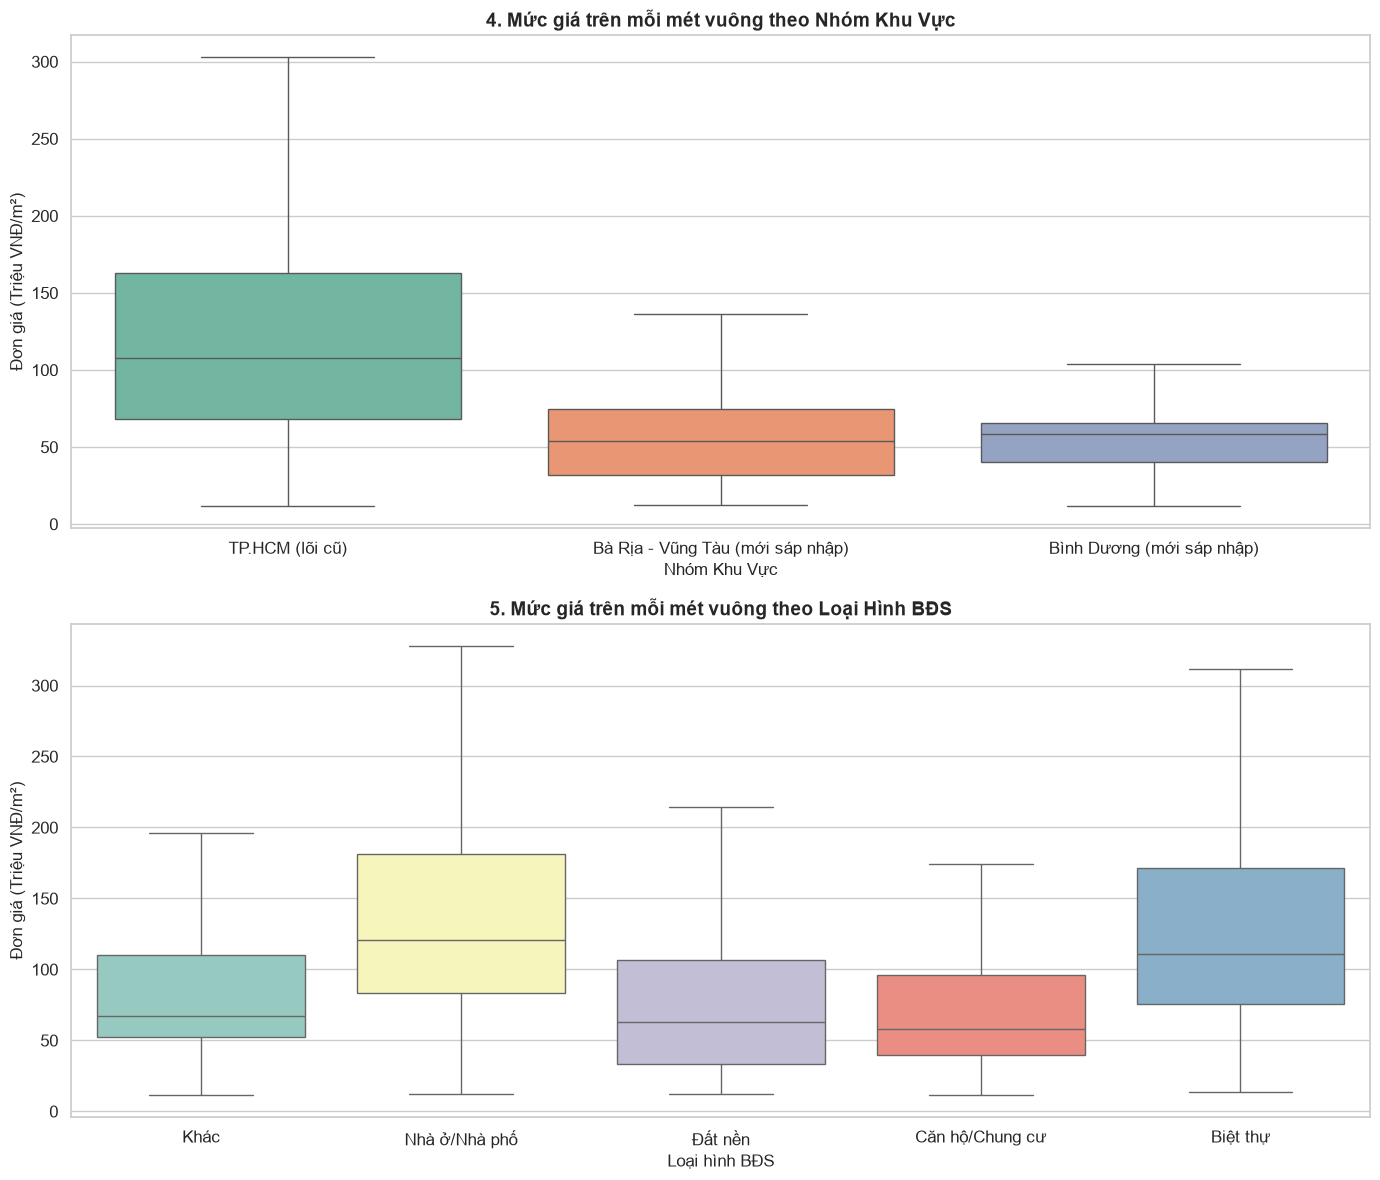

In [9]:
# Biểu đồ 4 & 5: Boxplot định giá theo khu vực và loại hình
fig, ax = plt.subplots(2, 1, figsize=(14, 12))

sns.boxplot(data=df, x='khu_vuc_nhom', y='price_per_m2_trieu', hue='khu_vuc_nhom', legend=False, palette='Set2', showfliers=False, ax=ax[0])
ax[0].set_title('4. Mức giá trên mỗi mét vuông theo Nhóm Khu Vực', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Nhóm Khu Vực', fontsize=12)
ax[0].set_ylabel('Đơn giá (Triệu VNĐ/m²)', fontsize=12)

sns.boxplot(data=df, x='loai_bds', y='price_per_m2_trieu', hue='loai_bds', legend=False, palette='Set3', showfliers=False, ax=ax[1])
ax[1].set_title('5. Mức giá trên mỗi mét vuông theo Loại Hình BĐS', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Loại hình BĐS', fontsize=12)
ax[1].set_ylabel('Đơn giá (Triệu VNĐ/m²)', fontsize=12)

plt.tight_layout()
plt.show()

- TP.HCM (lõi cũ) có mức giá/m² cao nhất và độ phân tán lớn nhất: trung vị khoảng 108 triệu đồng/m², trong khi Bà Rịa – Vũng Tàu và Bình Dương mới sáp nhập có trung vị lần lượt khoảng 54 và 58 triệu đồng/m²
- Nhà ở/Nhà phố có mức giá trung vị cao nhất, khoảng 120 triệu đồng/m², đồng thời biên độ giá rất rộng, cho thấy phân khúc này có sự khác biệt lớn giữa các sản phẩm. Căn hộ có trung vị khoảng 110 triệu đồng/m²
- Insight kinh doanh: doanh nghiệp không nên dùng một mức giá chung cho toàn TP.HCM mới mà cần xây dựng chiến lược theo khu vực, đặc biệt khai thác sự khác biệt về giá giữa khu lõi và các khu vực mới sáp nhập, xây dựng chiến lược giá phù hợp với từng địa bàn. Sự phân hóa giá theo loại hình là cơ sở để doanh nghiệp đa dạng hóa danh mục sản phẩm
- Insight kinh doanh: Nhà phố và căn hộ là hai nhóm có mức giá/m² trung vị cao, trong khi đất nền có mặt bằng thấp hơn và độ phân tán đáng kể. Do đó, doanh nghiệp có thể điều chỉnh cơ cấu sản phẩm theo từng khu vực để tận dụng sự khác biệt về nhu cầu và mặt bằng giá trong TP.HCM mới.

## 4. Tương quan Diện tích & Giá trị (Multivariate Analysis)
Mục tiêu: Khám phá sự thay đổi giá bán khi diện tích tăng lên, được phân cụm theo loại hình BĐS.

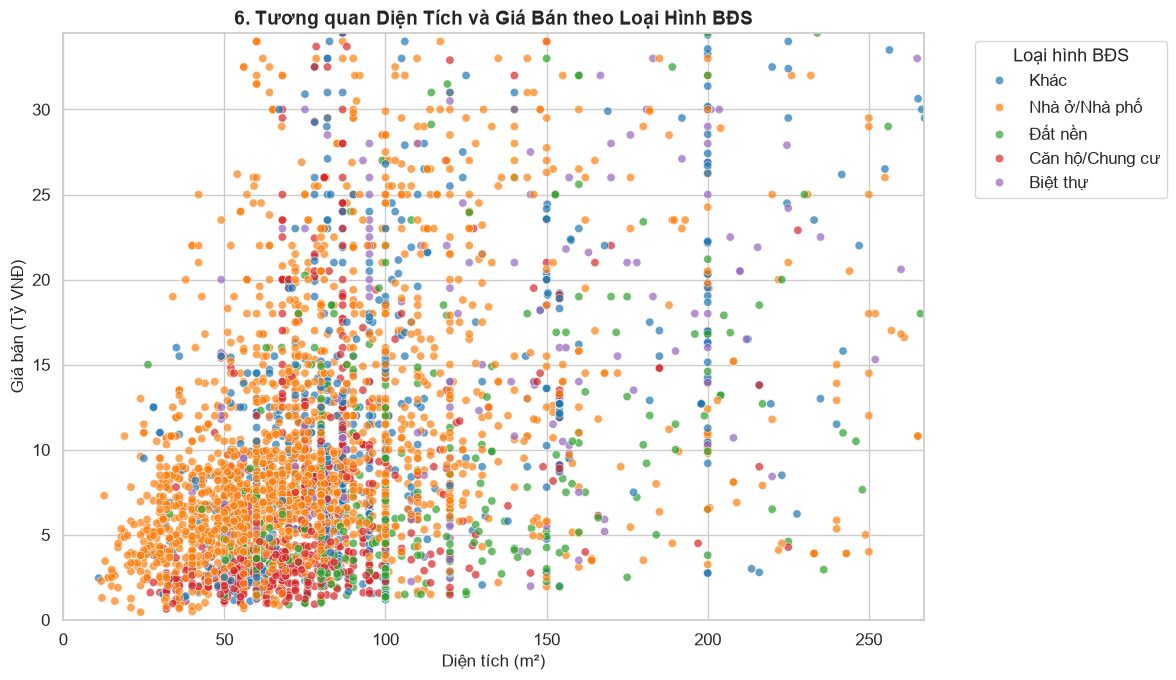

In [17]:
# Biểu đồ 6: Scatter Plot
fig, ax = plt.subplots(figsize=(12, 7))

sns.scatterplot(data=df, x='dien_tich', y='gia_ty', hue='loai_bds', alpha=0.7, palette='tab10', ax=ax)
ax.set_title('6. Tương quan Diện Tích và Giá Bán theo Loại Hình BĐS', fontsize=14, fontweight='bold')
ax.set_xlabel('Diện tích (m²)', fontsize=12)
ax.set_ylabel('Giá bán (Tỷ VNĐ)', fontsize=12)
ax.set_xlim(0, df['dien_tich'].quantile(0.98))
ax.set_ylim(0, df['gia_ty'].quantile(0.98))

plt.legend(title='Loại hình BĐS', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

- Biểu đồ cho thấy diện tích và giá bán có xu hướng đồng biến, nhưng mối quan hệ không quá chặt: các bất động sản có diện tích lớn thường có mức giá cao hơn, tuy nhiên cùng một diện tích vẫn xuất hiện nhiều mức giá khác nhau ==> vị trí, loại hình và đặc điểm tài sản có thể ảnh hưởng đáng kể đến giá bán ngoài yếu tố diện tích
- Nhà ở/Nhà phố tập trung dày nhất, chủ yếu ở nhóm diện tích khoảng 40–100 m² và giá khoảng 2–10 tỷ đồng, Biệt thự và Đất nền có phạm vi diện tích rộng hơn và xuất hiện nhiều điểm ở mức giá cao
- Insight kinh doanh: doanh nghiệp nên kết hợp diện tích + loại hình + khu vực để xây dựng mô hình định giá và xác định phân khúc khách hàng phù hợp cho từng khu vực của TP.HCM mới

## 5. Thị hiếu Cục bộ & Điểm nóng Đầu tư
Mục tiêu: Xác định vùng có thanh khoản cung cầu cao nhất (tin đăng nhiều nhất) và vùng định giá nóng nhất (Top 10 Phường/Xã đắt đỏ nhất).

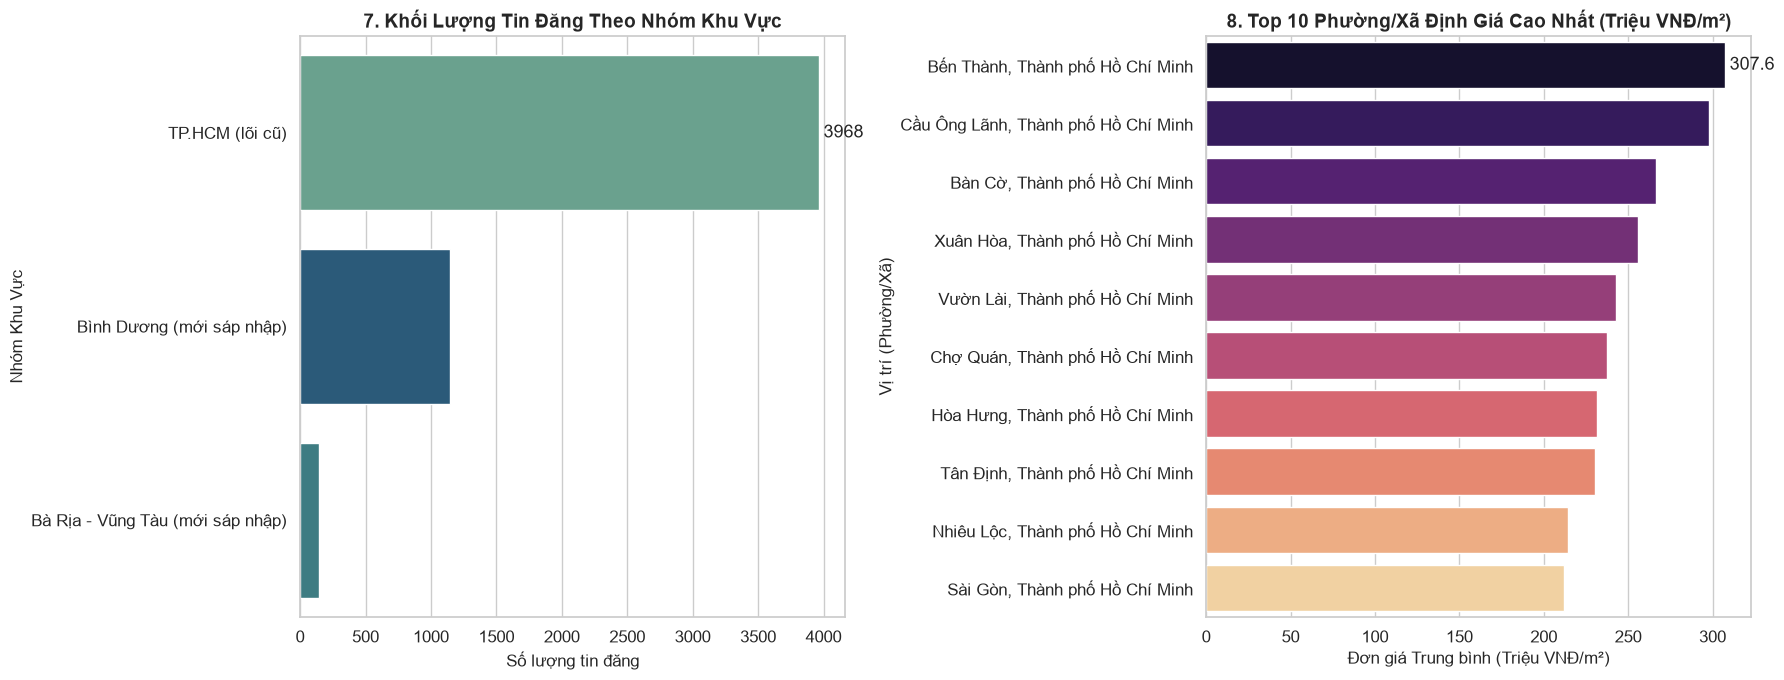

In [11]:
# Biểu đồ 7 & 8: Volume tin đăng và Top 10 Vị trí đắt đỏ
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# Biểu đồ 7
sns.countplot(data=df, y='khu_vuc_nhom', hue='khu_vuc_nhom', legend=False, order=df['khu_vuc_nhom'].value_counts().index, palette='crest', ax=ax[0])
ax[0].set_title('7. Khối Lượng Tin Đăng Theo Nhóm Khu Vực', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Số lượng tin đăng', fontsize=12)
ax[0].set_ylabel('Nhóm Khu Vực', fontsize=12)
ax[0].bar_label(ax[0].containers[0], padding=3)

# Biểu đồ 8
top_wards = df.groupby('vi_tri').filter(lambda x: len(x) >= 5) # Lọc nhiễu: chỉ lấy vị trí có từ 5 tin đăng trở lên
top10 = top_wards.groupby('vi_tri')['price_per_m2_trieu'].mean().sort_values(ascending=False).head(10)

sns.barplot(x=top10.values, y=top10.index, hue=top10.index, legend=False, palette='magma', ax=ax[1])
ax[1].set_title('8. Top 10 Phường/Xã Định Giá Cao Nhất (Triệu VNĐ/m²)', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Đơn giá Trung bình (Triệu VNĐ/m²)', fontsize=12)
ax[1].set_ylabel('Vị trí (Phường/Xã)', fontsize=12)
ax[1].bar_label(ax[1].containers[0], fmt='%.1f', padding=3)

plt.tight_layout()
plt.show()

- Nguồn cung giao dịch vẫn tập trung áp đảo ở khu vực lõi cũ (gấp gần 3.5 lần Bình Dương và gấp hơn 26 lần Bà Rịa - Vũng Tàu). Khu vực Bình Dương tỏ ra thích ứng và sôi động nhanh nhất trong số các địa phương mới sáp nhập nhờ hạ tầng kết nối sẵn có và nguồn cung căn hộ/đất nền dồi dào. Bà Rịa - Vũng Tàu chiếm tỷ trọng rất nhỏ, cho thấy thị trường tại đây chưa hình thành làn sóng niêm yết/giao dịch quy mô lớn trên hệ thống
- Top 10 đều thuộc các phường trung tâm lịch sử/lõi cũ của TP.HCM. Phường Bến Thành dẫn đầu vượt trội với mức định giá vượt mốc 300 triệu/m², Biên độ giá trung bình của Top 10 dao động từ 211 đến 307,6 triệu VNĐ/m². Không có bất kỳ phường/xã thuộc khu vực mới sáp nhập
- Insight: TP.HCM lõi cũ chiếm 75% nguồn cung nhờ thanh khoản cao (3.968 tin). Sự sáp nhập giúp Bình Dương bùng nổ giao dịch vệ tinh (~1.150 tin), trong khi Bà Rịa - Vũng Tàu (~150 tin) là điểm đón đầu đầu tư dài hạn
- Insight: Đất trung tâm lõi cũ giữ vị thế độc tôn với giá từ 211 - 307.6 triệu/m² (cao nhất là Bến Thành). Việc mở rộng địa giới củng cố giá trị "đất vàng", buộc các dịch vụ cao cấp tập trung ở trung tâm, còn dự án dòng tiền sẽ dạt về vùng mới sáp nhập.